In [1]:
from google.colab import drive
drive.mount('/content/drive')

import sys
sys.path.append('/content/drive/MyDrive/Colab Notebooks/ProyectoLINTatPromptGamma/')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Bibliotecas a utilizar.
Se importa el código Activación.py como una biblioteca.

In [3]:
import Activacion as act
import numpy as np
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt

## Rutas de archivos, nombres de fuentes y constantes.

In [83]:
#Espectros de fondo según detector y r_is
path_fondo = {'DF-OFF': "/content/drive/MyDrive/Colab Notebooks/ProyectoLINTatPromptGamma/2025-06-11_NAAPG_Beam/11.06.2025_PG_LINT/-txt/DF_fondo_rOFF_12.06.2025.txt",
              'XC-OFF': "/content/drive/MyDrive/Colab Notebooks/ProyectoLINTatPromptGamma/2025-06-11_NAAPG_Beam/11.06.2025_PG_LINT/-txt/XC_fondo_rOFF_12.06.2025.txt",
              'DF-ON': "/content/drive/MyDrive/Colab Notebooks/ProyectoLINTatPromptGamma/2025-06-11_NAAPG_Beam/11.06.2025_PG_LINT/-txt/DF_fondo_rON_10.06.2025.txt",
              'XC-ON': "/content/drive/MyDrive/Colab Notebooks/ProyectoLINTatPromptGamma/2025-06-11_NAAPG_Beam/11.06.2025_PG_LINT/-txt/XC_fondo_rON_10.06.2025.txt"}

#Nombre de la fuente patrón
Fuente_pat = 'Eu152_76044A-440'

#Espectros de Eu en .txt
path_Eu152 = {'DF-ON': "/content/drive/MyDrive/Colab Notebooks/ProyectoLINTatPromptGamma/2025-06-11_NAAPG_Beam/11.06.2025_PG_LINT/-txt/DF_Eu152_76044A_sep3_rON_11.06.2025.txt",
              'XC-ON': "/content/drive/MyDrive/Colab Notebooks/ProyectoLINTatPromptGamma/2025-06-11_NAAPG_Beam/11.06.2025_PG_LINT/-txt/XC_Eu152_76044A_3sep_rON_11.06.2025.txt",
              'XC-OFF': "/content/drive/MyDrive/Colab Notebooks/ProyectoLINTatPromptGamma/2025-06-11_NAAPG_Beam/11.06.2025_PG_LINT/-txt/XC_Eu152_76044A_3sep_rOFF_12.06.2025.txt"}

#Tablas de ROIs en .txt [E, inicio, fin]
path_Roical = {'DF-ON': "/content/drive/MyDrive/Colab Notebooks/ProyectoLINTatPromptGamma/2025-06-11_NAAPG_Beam/11.06.2025_PG_LINT/-txt/ROI_cal_DF_Eu152_rON.txt",
               'XC-ON': "/content/drive/MyDrive/Colab Notebooks/ProyectoLINTatPromptGamma/2025-06-11_NAAPG_Beam/11.06.2025_PG_LINT/-txt/ROI_cal_XC_Eu152_rON.txt",
               'XC-OFF': "/content/drive/MyDrive/Colab Notebooks/ProyectoLINTatPromptGamma/2025-06-11_NAAPG_Beam/11.06.2025_PG_LINT/-txt/ROI_cal_XC_Eu152_rOFF.txt"}

#Fuentes de Cs y Co según detector y r_is
fuente_Cs = {'DF-ON': 'Cs137_76072-440',
          'XC-ON': 'Cs137_76072-440',
          'XC-OFF': 'Cs137_76071-440'}

fuente_Co = {f:'Co60_76057-440' for f in ['DF-ON', 'XC-ON', 'XC-OFF']}

#Espectros de Cs y Co en .txt
path_incog_Cs = {'DF-ON': "/content/drive/MyDrive/Colab Notebooks/ProyectoLINTatPromptGamma/2025-06-11_NAAPG_Beam/11.06.2025_PG_LINT/-txt/DF_Cs137_76072_sep3_rON_11.06.2025.txt",
              'XC-ON': "/content/drive/MyDrive/Colab Notebooks/ProyectoLINTatPromptGamma/2025-06-11_NAAPG_Beam/11.06.2025_PG_LINT/-txt/XC_Cs137_76072_3sep_rON_11.06.2025.txt",
              'XC-OFF': "/content/drive/MyDrive/Colab Notebooks/ProyectoLINTatPromptGamma/2025-06-11_NAAPG_Beam/11.06.2025_PG_LINT/-txt/XC_Cs137_76071_3sep_rOFF_12.06.2025.txt"}

path_incog_Co = {'DF-ON': "/content/drive/MyDrive/Colab Notebooks/ProyectoLINTatPromptGamma/2025-06-11_NAAPG_Beam/11.06.2025_PG_LINT/-txt/DF_Co60_76057_sep3_rON_11.06.2025.txt",
                 'XC-OFF': "/content/drive/MyDrive/Colab Notebooks/ProyectoLINTatPromptGamma/2025-06-11_NAAPG_Beam/11.06.2025_PG_LINT/-txt/XC_Co60_76057_3sep_rOFF_12.06.2025.txt",
                 'XC-ON': "/content/drive/MyDrive/Colab Notebooks/ProyectoLINTatPromptGamma/2025-06-11_NAAPG_Beam/11.06.2025_PG_LINT/-txt/XC_Co60_76057_3sep_rON_11.06.2025.txt"}

#Rois para espectros de Cs y Co.
ROIs_Cs = {'DF-ON': np.array([1160, 1174]),
          'XC-ON': np.array([1108, 1122]),
          'XC-OFF': np.array([1109, 1121])}

ROIs_Co = {'DF-ON': np.array([[2370, 2388], [2082, 2100]]),
           'XC-ON': np.array([[1992, 2006], [2268, 2282]]),
           'XC-OFF': np.array([[1993, 2007], [2268, 2282]])}


#ROis y paths de las hojuelas
ROIs_MnCu = {'Mn209-1': {'56Mn': [1495, 1509]},
             'Mn203-1': {'56Mn': [1494, 1508]},
             'Mn209-2': {'56Mn': [1427, 1443]},
             'Mn209-3': {'56Mn': [1427, 1443]}}

paths_MnCu = {'Mn209-1': '/content/drive/MyDrive/Colab Notebooks/ProyectoLINTatPromptGamma/2025-06-11_NAAPG_Beam/11.06.2025_PG_LINT/-txt/DF_Mn209_sep3_rON_11.06.2025_med1.txt',
              'Mn203-1': '/content/drive/MyDrive/Colab Notebooks/ProyectoLINTatPromptGamma/2025-06-11_NAAPG_Beam/11.06.2025_PG_LINT/-txt/DF_Mn203_sep3_rON_11.06.2025_med1.txt',
              'Mn209-2': '/content/drive/MyDrive/Colab Notebooks/ProyectoLINTatPromptGamma/2025-06-11_NAAPG_Beam/11.06.2025_PG_LINT/-txt/XC_Mn209_3sep_rOFF_12.06.2025_med2.txt',
              'Mn209-3': '/content/drive/MyDrive/Colab Notebooks/ProyectoLINTatPromptGamma/2025-06-11_NAAPG_Beam/11.06.2025_PG_LINT/-txt/XC_Mn209_3sep_rOFF_12.06.2025_med3.txt'}

#Constantes para definir las hojuelas: masas, errores relativos de las masas, error estándar del tiempo de irradiación.
masas = {'Mn210': 49.9e-3, 'Mn203': 50.3e-3, 'Mn209': 50e-3}
err_rel_m = 0.005 #%m/m
tirr_err = 1 #s


## Calibraciones en eficiencia

### DF-ON

Para el germanio '**Física**' con reactor encendido (ON).

In [ ]:
hpge = 'DF-ON'

Grafico el fondo

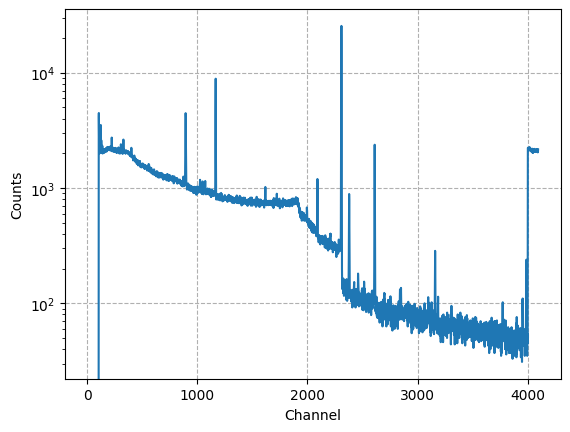

In [13]:
act.fromspec(path_fondo[hpge]).graph()

y el espectro del patrón

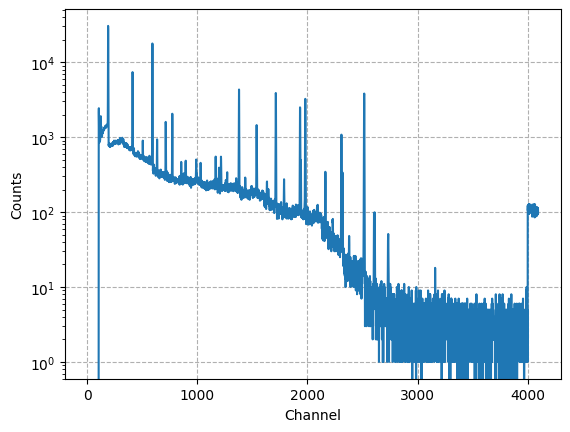

In [14]:
act.fromspec(path_Eu152[hpge]).graph()

La calibración en energía se considera hecha desde el Gammavision o Maestro. Queda guardado en el espectro y se aprovecha para la calibración en eficiencia.

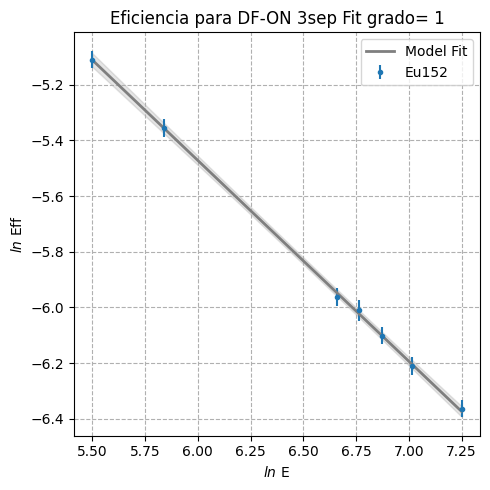

In [47]:
dfon = act.HPGE_calib(hpge, path_Eu152[hpge], path_fondo[hpge])
dfon.eff(path_Roical[hpge]) #Calibración en eficiencia

Con parámetros de ajuste:

In [43]:
for jj in range(2):
    print(f'a{1-jj} = '+ ' '.join([*act.redondeo(*dfon.eff_coef_tabla[jj, :], cs=2, texto=True)]))

a1 = -0.721 ± 0.020
a0 = -1.15 ± 0.13


La bondad del ajuste se reporta a continuación:

In [48]:
dfon.eff_goodness #p-value --> 1, sobreestimación de los errores.

,goodness of fit
chi^2,0.587208
p-value,0.988581
ddof,5.000000
R^2,0.999487


También se pueden agregar datos de picos de otros espectros. En este caso, se agregan los de Cs-137 y Co-60:

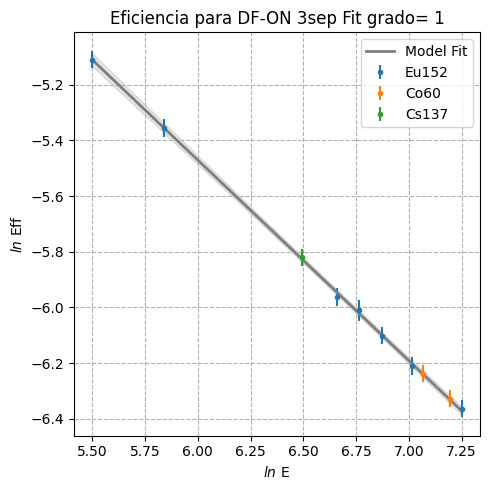

In [49]:
dfon.eff_adddata(path_incog_Co[hpge], ROIs_Co[hpge], npicos = 2, fuente = fuente_Co[hpge], graph = False)
dfon.eff_adddata(path_incog_Cs[hpge], ROIs_Cs[hpge], npicos = 1, fuente = fuente_Cs[hpge])

In [50]:
for jj in range(2):
    print(f'a{1-jj} = '+ ' '.join([*act.redondeo(*dfon.eff_coef_tabla[jj, :], cs=2, texto=True)]))

a1 = -0.72 ± 0.018
a0 = -1.15 ± 0.12


In [51]:
dfon.eff_goodness #p-value --> 1, sobreestimación de los errores.

,goodness of fit
chi^2,0.664459
p-value,0.999610
ddof,8.000000
R^2,0.999539


### XC-OFF

Se repite el procedimiento con el otro detector de germanio, '**XCooler**', sumando la condición de reactor apagado (OFF).

Para abreviar, se saltean ciertos pasos y se devuelven los resultados.

In [54]:
hpge = 'XC-OFF'

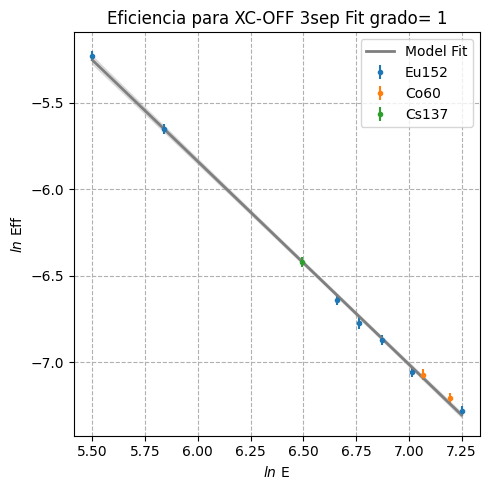

In [58]:
xcoff = act.HPGE_calib(hpge, path_Eu152[hpge], path_fondo[hpge])
xcoff.eff(path_Roical[hpge], graph = False) #Calibración en eficiencia
#Agrego datos de otros espectros y ajusto:
xcoff.eff_adddata(path_incog_Co[hpge], ROIs_Co[hpge], npicos = 2, fuente = fuente_Co[hpge], graph = False)
xcoff.eff_adddata(path_incog_Cs[hpge], ROIs_Cs[hpge], npicos = 1, fuente = fuente_Cs[hpge])

In [59]:
for jj in range(2):
    print(f'a{1-jj} = '+ ' '.join([*act.redondeo(*xcoff.eff_coef_tabla[jj, :], cs=2, texto=True)]))

a1 = -1.173 ± 0.018
a0 = 1.2 ± 0.12


In [60]:
xcoff.eff_goodness #p-value --> 0.7 + Chi2 --> ddof : ajuste OK.

,goodness of fit
chi^2,5.697208
p-value,0.681107
ddof,8.000000
R^2,0.998637


###XC-ON

In [61]:
hpge = 'XC-ON'

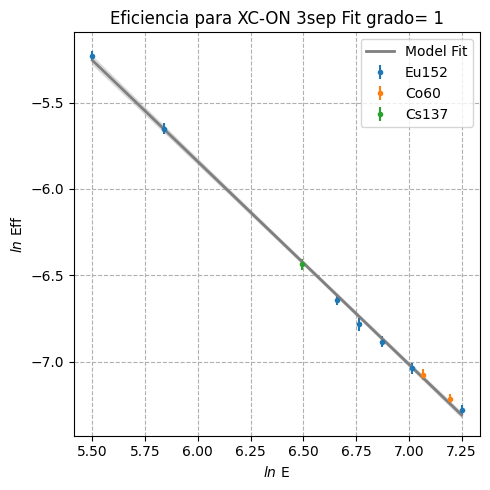

In [62]:
xcon = act.HPGE_calib(hpge, path_Eu152[hpge], path_fondo[hpge])
xcon.eff(path_Roical[hpge], graph = False) #Calibración en eficiencia
#Agrego datos de otros espectros y ajusto:
xcon.eff_adddata(path_incog_Co[hpge], ROIs_Co[hpge], npicos = 2, fuente = fuente_Co[hpge], graph = False)
xcon.eff_adddata(path_incog_Cs[hpge], ROIs_Cs[hpge], npicos = 1, fuente = fuente_Cs[hpge])

In [63]:
for jj in range(2):
    print(f'a{1-jj} = '+ ' '.join([*act.redondeo(*xcon.eff_coef_tabla[jj, :], cs=2, texto=True)]))

a1 = -1.172 ± 0.018
a0 = 1.19 ± 0.12


In [64]:
xcon.eff_goodness #p-value --> 0.7 + Chi2 --> ddof : ajuste OK.

,goodness of fit
chi^2,5.256223
p-value,0.729872
ddof,8.000000
R^2,0.998634


## Cálculo de actividad y flujo neutrónico.

Todas las hojuelas tienen la misma composición, y fueron irradiadas al mismo tiempo. Sus espectros desde los detectores de germanio, sin embargo, fueron medidos en distintos tiempos y condiciones.

In [65]:
Composition = {'55Mn': 0.8123, '63Cu': 0.1877}
tirr = 16200 + 696
t_inicio = datetime(2025, 6, 11, 14, 41, 36)

###Mn203

La única medición se hizo con el DF, en condiciones de reactor encendido.

In [68]:
med = 'Mn203-1'

In [69]:
mn203_1 = act.Alambre(dfon, Composition, tirr, paths_MnCu[med], t_inicio)

In [70]:
mn203_1.pico(ROIs_MnCu[med], graph_ROI=False)

,tasa,tasa_err
56Mn,0.08159,0.003458


In [71]:
mn203_1.calcular_act()

,Fuente,Energía [keV],Act [Bq],dAct [Bq]
0,56Mn,846.1955880317936,116.15529043447515,5.063257288120407


In [73]:
mn203_1.calc_flujo(masas[med.split('-')[0]], err_rel_m)

,Fuente,Flujo [nv],dFlujo [nv]
0,56Mn,32467.051832931782,1424.5324150819035


### Mn209

La primera medición se hizo con el DF, en condiciones de reactor encendido.

In [74]:
med = 'Mn209-1'

In [77]:
mn209_1 = act.Alambre(dfon, Composition, tirr, paths_MnCu[med], t_inicio)

In [78]:
mn209_1.pico(ROIs_MnCu[med], graph_ROI=False)

,tasa,tasa_err
56Mn,161.398164,1.290298


In [79]:
mn209_1.calcular_act()

,Fuente,Energía [keV],Act [Bq],dAct [Bq]
0,56Mn,846.7485207655744,76392.41534820618,990.0510208541582


In [80]:
mn209_1.calc_flujo(masas[med.split('-')[0]], err_rel_m)

,Fuente,Flujo [nv],dFlujo [nv]
0,56Mn,21480880.62517577,298394.310032719


La segunda y tercera medición se hicieron en XC, con reactor apagado.

In [81]:
med = 'Mn209-2'

In [89]:
mn209_2 = act.Alambre(xcoff, Composition, tirr, paths_MnCu[med], t_inicio)

In [90]:
mn209_2.pico(ROIs_MnCu[med], graph_ROI=False)

,tasa,tasa_err
56Mn,1.704917,0.00891


In [91]:
mn209_2.calcular_act()

,Fuente,Energía [keV],Act [Bq],dAct [Bq]
0,56Mn,846.5078057110725,78000.23200783791,875.4811718341888


In [92]:
mn209_2.calc_flujo(masas[med.split('-')[0]], err_rel_m)

,Fuente,Flujo [nv],dFlujo [nv]
0,56Mn,21932984.640676428,269500.0140154013


Tercera med:

In [93]:
med = 'Mn209-3'

In [94]:
mn209_3 = act.Alambre(xcoff, Composition, tirr, paths_MnCu[med], t_inicio)

In [95]:
mn209_3.pico(ROIs_MnCu[med], graph_ROI=False)

,tasa,tasa_err
56Mn,0.479549,0.008878


In [96]:
mn209_3.calcular_act()

,Fuente,Energía [keV],Act [Bq],dAct [Bq]
0,56Mn,846.5078057110725,75355.23530876687,1583.2360804757316


In [97]:
mn209_3.calc_flujo(masas[med.split('-')[0]], err_rel_m)

,Fuente,Flujo [nv],dFlujo [nv]
0,56Mn,21189234.648118258,457625.4491072573
